In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
df = pd.read_csv(r"C:\Machine learning Campusx\Data\Wine_Dataset.csv")

In [76]:
df.head(5)

,Malic acid,Ashe,Alcalinity of ashe,Magnesium,Total phenols,Flavanoidse,Nonflavanoid phenols,Proanthocyanins,Color intensity,OD280,OD31,Proline,Alcohol
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,1


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Malic acid            178 non-null    float64
 1   Ashe                  178 non-null    float64
 2   Alcalinity of ashe    178 non-null    float64
 3   Magnesium             178 non-null    float64
 4   Total phenols         178 non-null    int64  
 5   Flavanoidse           178 non-null    float64
 6   Nonflavanoid phenols  178 non-null    float64
 7   Proanthocyanins       178 non-null    float64
 8   Color intensity       178 non-null    float64
 9   OD280                 178 non-null    float64
 10  OD31                  178 non-null    float64
 11  Proline               178 non-null    float64
 12  Alcohol               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [78]:
df.describe()

,Malic acid,Ashe,Alcalinity of ashe,Magnesium,Total phenols,Flavanoidse,Nonflavanoid phenols,Proanthocyanins,Color intensity,OD280,OD31,Proline,Alcohol
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,3.000000


In [79]:
df.columns

Index(['Malic acid', 'Ashe', 'Alcalinity of ashe', 'Magnesium',
       'Total phenols', 'Flavanoidse', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'OD280', 'OD31', 'Proline',
       'Alcohol'],
      dtype='object')

In [80]:
X = df.drop(columns = ['Alcohol'])
y = df['Alcohol']

In [81]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(X , y, test_size = 0.3, random_state = 0)

In [82]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,  columns = X_train.columns)

<Axes: title={'center': 'After scaling'}, xlabel='Malic acid', ylabel='Density'>

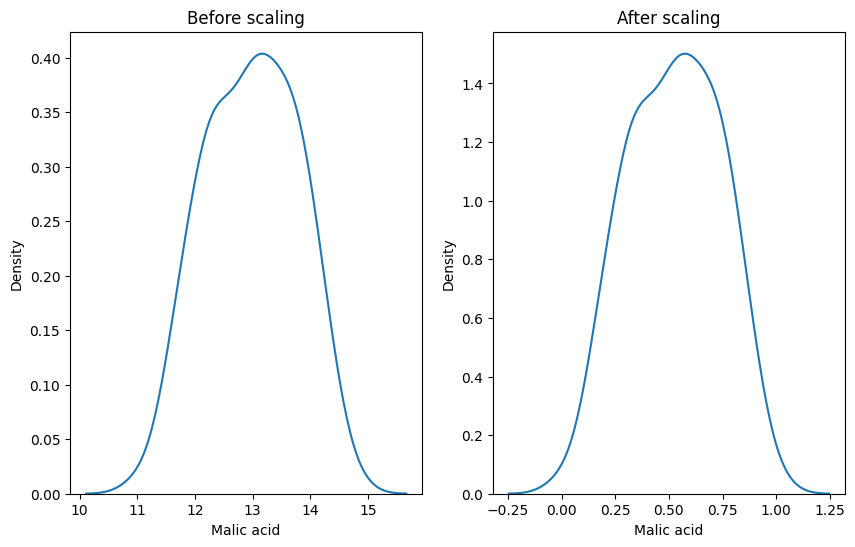

In [84]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2, figsize = (10,6))
ax1.set_title("Before scaling")
sns.kdeplot(data = X_train , x = 'Malic acid' , ax = ax1)
ax2.set_title("After scaling")
sns.kdeplot(data = X_train_scaled , x = 'Malic acid' , ax = ax2)

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr_scaled = LinearRegression()

lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled , y_train)

y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)


In [86]:
from sklearn.metrics import r2_score
print(f"Before scaling : {r2_score(y_test, y_pred)}")
print(f"After scaling : {r2_score(y_test, y_pred_scaled)}")

Before scaling : 0.8055432839638557
After scaling : 0.8055432839638558
